# 2. Lick Detection (tongue + chin)

Detect individual licks from the DLC `tongue` bodypart, use `chin` as the
bout envelope / QC, and put every lick on the VR clock.

- **`tongue`** is only on-screen during a lick (~5 % of frames) — each
  contiguous "tongue visible" run = one lick. Mouse licking is 6–9 Hz; the
  inter-lick-interval histogram is the sanity check.
- **`chin`** is visible more continuously while the mouth is active (~12 %
  of frames) — it defines the licking *bout* and backs up the tongue where
  DLC drops it (video quality).

Reads `{rec}_lickproc.h5` from notebook 1; writes `licks` / `bouts` back into it.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import find_peaks

MODULE_DIR = r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\10.LickingBehavior"
sys.path.insert(0, MODULE_DIR)
from lick_io import read_vrlog
from lick_sync import frame_to_vr, vr_to_frame, load_sync_model

# ---------------- CONFIG ----------------
RECORDING_FOLDER = r"F:\dlc\test"
RECORDING        = None                # None = auto from the lickproc file
FPS              = 30.0

# tongue -> individual licks (peaks in the tongue-likelihood trace)
TONGUE_P     = 0.30       # min peak height in tongue likelihood
LICK_MIN_SEP = 2          # min frames between licks (-> max 15 Hz; mice lick 6-9)
TONGUE_BOX   = ((520, 595), (490, 560))   # ((x0,x1),(y0,y1)) reject peaks with the point parked off the tongue

# chin -> licking bouts
CHIN_P       = 0.40        # likelihood cutoff (on a 5-frame smoothed trace)
CHIN_SMOOTH  = 5
BOUT_MIN     = 6          # min bout length (frames)  ~0.2 s
BOUT_GAP     = 12         # merge bouts separated by <= this many frames  ~0.4 s
BOUT_PAD     = 6          # frames of slack when assigning a lick to a bout

plt.rcParams["figure.dpi"] = 110

## Load notebook-1 output

In [2]:
lp = glob.glob(os.path.join(RECORDING_FOLDER, "*_lickproc.h5"))
assert lp, f"no *_lickproc.h5 in {RECORDING_FOLDER} — run 1.Preprocess.ipynb first"
LICKPROC_H5 = lp[0]

with h5py.File(LICKPROC_H5, "r") as f:
    COORD_NAMES = [x.decode() if isinstance(x, bytes) else x
                   for x in f["pose"].attrs["coord_names"]]
    POSE  = f["pose/data"][:]
    FRAME = f["pose/frame"][:]
    trial_df = pd.DataFrame({k: f["trials"][k][:] for k in f["trials"]})
    RECORDING      = f.attrs["recording"]
    REWARD_ZONE_AU = float(f.attrs["reward_zone_au"])
    VRLOG_PATH     = f.attrs["vrlog_path"]

model = load_sync_model(LICKPROC_H5)
vr = read_vrlog(VRLOG_PATH)
N_FRAMES = len(POSE)

def col(name):
    return POSE[:, COORD_NAMES.index(name)]

print(f"recording : {RECORDING}   frames: {N_FRAMES}")
print(f"sync      : fps {model['fps_eff']:.4f}   resid {model['resid_sd_ms']:.1f} ms")
print(f"trials    : {len(trial_df)}   reward zone ~ {REWARD_ZONE_AU:.0f} au")
trial_df.head(3)

recording : 260618_JSY083_B1   frames: 54719
sync      : fps 29.9995   resid 15.6 ms
trials    : 98   reward zone ~ 392 au


,led_ok,n_anchor_frame,n_flash_frame,n_flash_resid_ms,n_time_vr,r_anchor_frame,r_flash_frame,r_flash_resid_ms,r_time_vr,reward_pos_au,trial
0,True,252.973960,NaN,NaN,0.00000,667.023187,667.0,-0.772908,13.30174,391.3072,1.0
1,True,697.316989,697.0,-10.566290,14.81121,1332.290761,1333.0,23.641296,35.47699,392.2061,2.0
2,True,1362.518862,1362.0,-17.295387,36.98427,1785.695727,1785.0,-23.190895,50.59026,392.9342,3.0


## 1. Detect licks (`tongue`) and bouts (`chin`)

In [3]:
def detect_licks(pose, coord_names, p=TONGUE_P, min_sep=LICK_MIN_SEP, box=TONGUE_BOX):
    # each lick = a peak in the tongue-likelihood trace (tongue protrusion).
    # peak-picking > threshold-crossing here: recovers licks whose likelihood
    # only briefly rises (double-interval rate ~11% -> ~7%).
    tx = pose[:, coord_names.index("tongue_x")]
    ty = pose[:, coord_names.index("tongue_y")]
    tl = pose[:, coord_names.index("tongue_likelihood")]
    pk, _ = find_peaks(tl, height=p, distance=min_sep)
    (x0, x1), (y0, y1) = box
    keep = (tx[pk] > x0) & (tx[pk] < x1) & (ty[pk] > y0) & (ty[pk] < y1)
    pk = pk[keep]
    vis = tl > p                        # for the per-bout coverage metric
    return pk, vis


def detect_bouts(pose, coord_names, p=CHIN_P, smooth=CHIN_SMOOTH,
                 min_len=BOUT_MIN, gap=BOUT_GAP):
    cl = pose[:, coord_names.index("chin_likelihood")]
    cs = np.convolve(cl, np.ones(smooth) / smooth, mode="same")
    on = cs > p
    d = np.diff(np.r_[0, on.astype(int), 0])
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    bouts = []
    for s, e in zip(starts, ends):
        if bouts and s - bouts[-1][1] <= gap:
            bouts[-1][1] = e
        else:
            bouts.append([s, e])
    bouts = [b for b in bouts if b[1] - b[0] >= min_len]
    return np.array(bouts, dtype=int).reshape(-1, 2), cs


lick_frames, tongue_vis = detect_licks(POSE, COORD_NAMES)
bouts, chin_smooth = detect_bouts(POSE, COORD_NAMES)

# assign each lick to a bout (with a little slack)
lick_bout = np.full(len(lick_frames), -1)
for bi, (bs, be) in enumerate(bouts):
    m = (lick_frames >= bs - BOUT_PAD) & (lick_frames < be + BOUT_PAD)
    lick_bout[m] = bi

ili = np.diff(lick_frames) / FPS * 1000
ili_in = ili[(ili > 40) & (ili < 400)]          # plausible lick-to-lick

print(f"{len(lick_frames)} licks   ({len(lick_frames)/(N_FRAMES/FPS/60):.0f} / min)")
print(f"inter-lick interval: median {np.median(ili_in):.0f} ms  -> {1000/np.median(ili_in):.1f} Hz   "
      f"(n={len(ili_in)})")
print(f"{len(bouts)} chin bouts   (median {np.median(np.diff(bouts,1).ravel())/FPS:.1f} s, "
      f"{np.median([np.sum(lick_bout==i) for i in range(len(bouts))]):.0f} licks/bout)")
print(f"licks outside any bout: {np.sum(lick_bout < 0)} ({np.mean(lick_bout < 0)*100:.0f} %)")

# per-bout tongue coverage = fraction of bout frames with tongue visible
bout_cov = np.array([tongue_vis[bs:be].mean() for bs, be in bouts])
print(f"per-bout tongue coverage: median {np.median(bout_cov):.2f}  "
      f"(< 0.05 in {np.sum(bout_cov < 0.05)} bouts -> tongue tracking lost there)")

1572 licks   (52 / min)
inter-lick interval: median 133 ms  -> 7.5 Hz   (n=1307)
162 chin bouts   (median 1.4 s, 8 licks/bout)
licks outside any bout: 72 (5 %)
per-bout tongue coverage: median 0.39  (< 0.05 in 12 bouts -> tongue tracking lost there)


### Diagnostic — traces around rewards

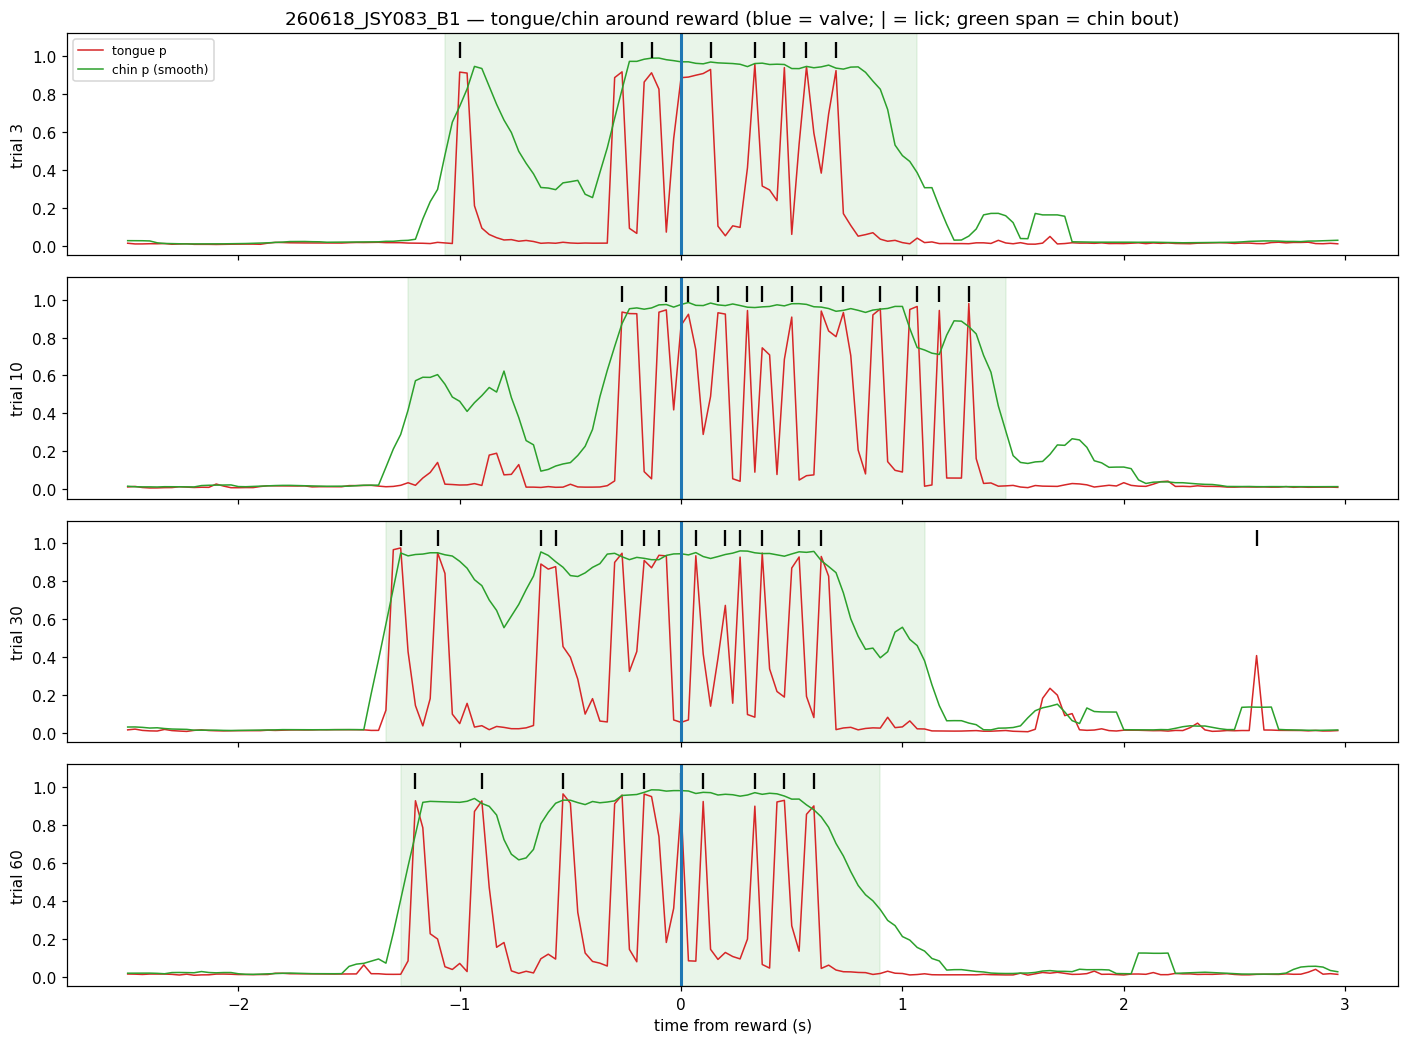

In [4]:
tl = col("tongue_likelihood"); cl = col("chin_likelihood")
show = [t for t in [3, 10, 30, 60, 90] if t <= len(trial_df)][:4]

fig, axs = plt.subplots(len(show), 1, figsize=(13, 2.4 * len(show)), sharex=True)
for ax, tn in zip(np.atleast_1d(axs), show):
    ra = trial_df.r_anchor_frame.iloc[tn - 1]
    if np.isnan(ra):
        continue
    ra = int(ra)
    lo, hi = ra - 75, ra + 90
    x = (np.arange(lo, hi) - ra) / FPS
    ax.plot(x, tl[lo:hi], color="tab:red", lw=1, label="tongue p")
    ax.plot(x, chin_smooth[lo:hi], color="tab:green", lw=1, label="chin p (smooth)")
    for bs, be in bouts:
        if be > lo and bs < hi:
            ax.axvspan((max(bs, lo) - ra) / FPS, (min(be, hi) - ra) / FPS,
                       color="tab:green", alpha=0.10)
    lk = lick_frames[(lick_frames >= lo) & (lick_frames < hi)]
    ax.plot((lk - ra) / FPS, np.full(len(lk), 1.03), "|", color="k", ms=10, mew=1.5)
    ax.axvline(0, color="tab:blue", lw=2)
    ax.set_ylim(-0.05, 1.12); ax.set_ylabel(f"trial {tn}")
np.atleast_1d(axs)[0].legend(loc="upper left", fontsize=8)
np.atleast_1d(axs)[0].set_title(f"{RECORDING} — tongue/chin around reward "
                                "(blue = valve; | = lick; green span = chin bout)")
np.atleast_1d(axs)[-1].set_xlabel("time from reward (s)")
plt.tight_layout(); plt.show()

### Diagnostic — lick frequency (the sanity check)

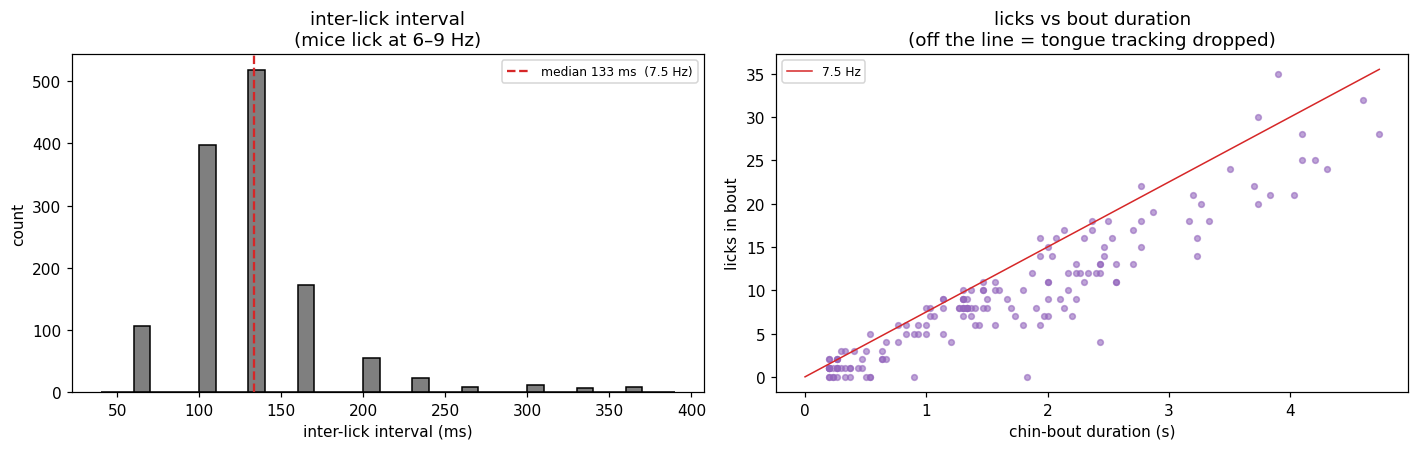

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))

axs[0].hist(ili_in, bins=np.arange(40, 400, 10), color="tab:gray", edgecolor="k")
axs[0].axvline(np.median(ili_in), color="tab:red", ls="--",
               label=f"median {np.median(ili_in):.0f} ms  ({1000/np.median(ili_in):.1f} Hz)")
axs[0].set_xlabel("inter-lick interval (ms)"); axs[0].set_ylabel("count")
axs[0].set_title("inter-lick interval\n(mice lick at 6–9 Hz)"); axs[0].legend(fontsize=8)

bl = np.diff(bouts, 1).ravel() / FPS
bn = np.array([np.sum(lick_bout == i) for i in range(len(bouts))])
axs[1].scatter(bl, bn, s=14, alpha=0.6, color="tab:purple")
xx = np.linspace(0, bl.max(), 50)
axs[1].plot(xx, xx * (1000 / np.median(ili_in)), color="tab:red", lw=1,
            label=f"{1000/np.median(ili_in):.1f} Hz")
axs[1].set_xlabel("chin-bout duration (s)"); axs[1].set_ylabel("licks in bout")
axs[1].set_title("licks vs bout duration\n(off the line = tongue tracking dropped)")
axs[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Diagnostic — licks over the session

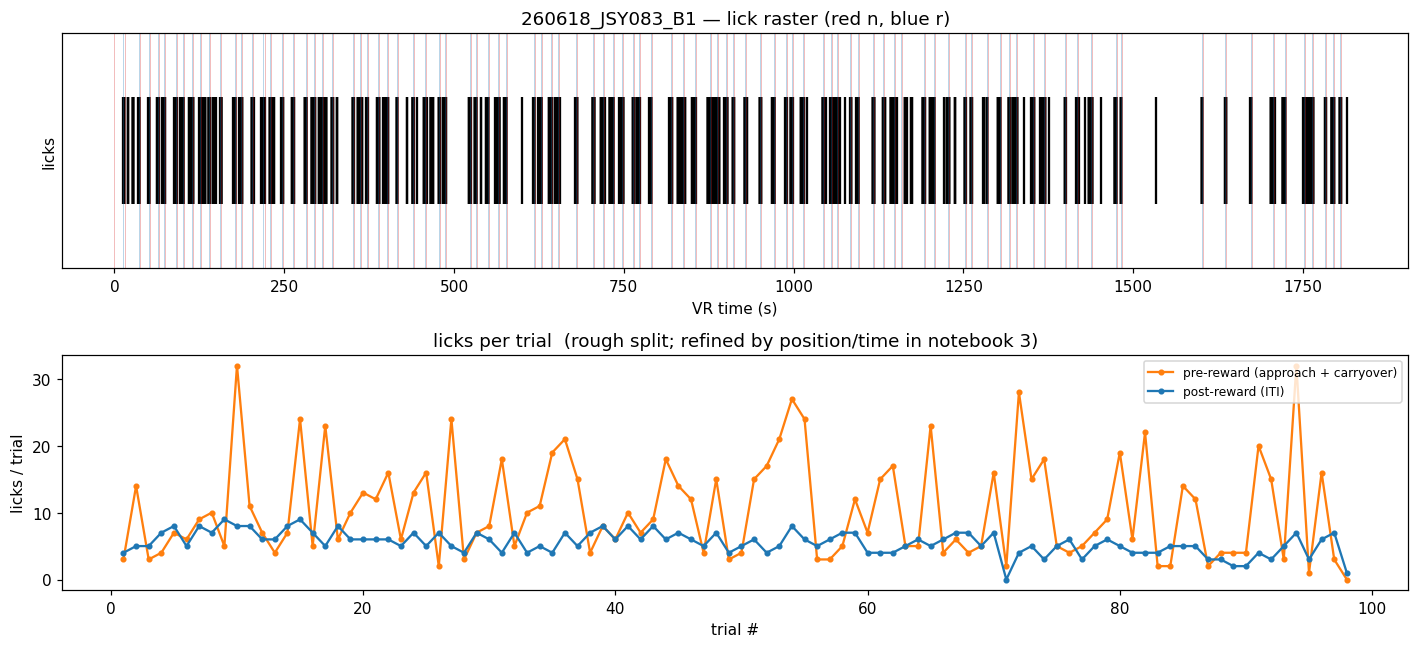

licks/trial  pre-reward 10.5   post-reward 5.5
trials with >=1 pre-reward lick: 97/98


In [6]:
lick_t = frame_to_vr(lick_frames, model, "generic")

# assign each lick to a trial + phase
n_anchor = trial_df.n_anchor_frame.to_numpy()
r_anchor = trial_df.r_anchor_frame.to_numpy()
edges = np.r_[n_anchor, N_FRAMES]
lick_trial = np.clip(np.searchsorted(edges, lick_frames, "right"), 1, len(trial_df))
lick_phase = np.where(lick_frames < r_anchor[lick_trial - 1], "antic", "consum")

n_ant = np.array([np.sum((lick_trial == t) & (lick_phase == "antic")) for t in trial_df.trial])
n_con = np.array([np.sum((lick_trial == t) & (lick_phase == "consum")) for t in trial_df.trial])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(13, 6))
ax0.eventplot([lick_t], colors="k", lineoffsets=0, linelengths=0.8)
for t in vr.n_times:
    ax0.axvline(t, color="tab:red", lw=0.4, alpha=0.5)
for t in vr.r_times:
    ax0.axvline(t, color="tab:blue", lw=0.4, alpha=0.5)
ax0.set_yticks([]); ax0.set_ylabel("licks"); ax0.set_xlabel("VR time (s)")
ax0.set_title(f"{RECORDING} — lick raster (red n, blue r)")

ax1.plot(trial_df.trial, n_ant, "-o", ms=3, color="tab:orange", label="pre-reward (approach + carryover)")
ax1.plot(trial_df.trial, n_con, "-o", ms=3, color="tab:blue", label="post-reward (ITI)")
ax1.set_xlabel("trial #"); ax1.set_ylabel("licks / trial"); ax1.legend(fontsize=8)
ax1.set_title("licks per trial  (rough split; refined by position/time in notebook 3)")

plt.tight_layout(); plt.show()
print(f"licks/trial  pre-reward {n_ant.mean():.1f}   post-reward {n_con.mean():.1f}")
print(f"trials with >=1 pre-reward lick: {np.sum(n_ant >= 1)}/{len(n_ant)}")

## 2. Licks on the VR clock + position

`lick_pos` is NaN for consummatory licks (position isn't logged during the
ITI) — those are handled by time-alignment in notebook 3.

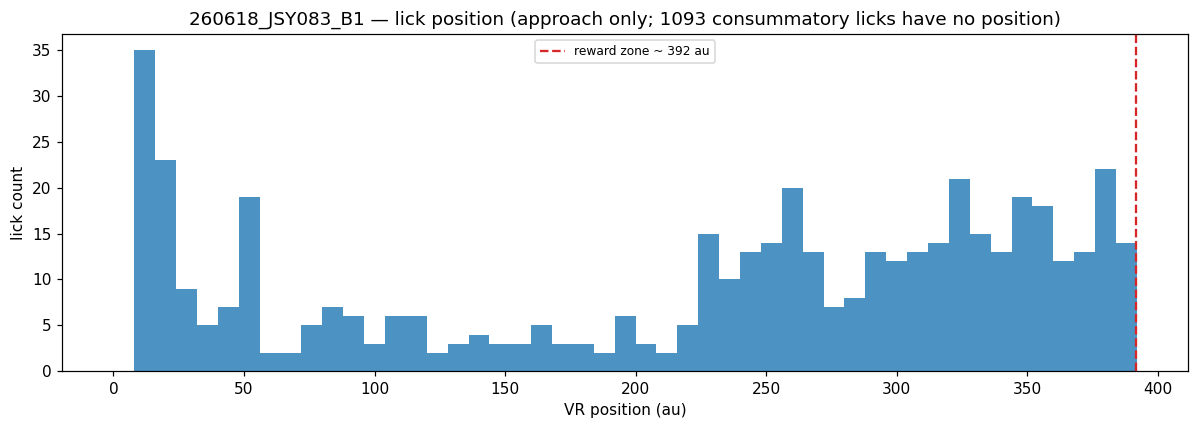

,frame,vr_time,position_au,trial,phase,bout_id
0,659,13.284150,NaN,1,antic,1
1,663,13.417482,NaN,1,antic,1
2,666,13.517480,NaN,1,antic,1
3,670,13.650812,NaN,1,consum,1
4,673,13.750810,NaN,1,consum,1


In [7]:
lick_pos = vr.position_at(lick_t, method="linear", max_gap_s=0.5)

licks_df = pd.DataFrame({
    "frame":     lick_frames,
    "vr_time":   lick_t,
    "position_au": lick_pos,
    "trial":     lick_trial,
    "phase":     lick_phase,
    "bout_id":   lick_bout,
})

fig, ax = plt.subplots(figsize=(11, 4))
m = np.isfinite(lick_pos)
ax.hist(lick_pos[m], bins=np.arange(0, 400, 8), color="tab:blue", alpha=0.8)
ax.axvline(REWARD_ZONE_AU, color="tab:red", ls="--", label=f"reward zone ~ {REWARD_ZONE_AU:.0f} au")
ax.set_xlabel("VR position (au)"); ax.set_ylabel("lick count")
ax.set_title(f"{RECORDING} — lick position (approach only; {(~m).sum()} consummatory licks have no position)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

licks_df.head()

## 3. Save `licks` / `bouts` into `*_lickproc.h5`

In [8]:
def save_licks(path, licks_df, bouts, bout_cov, lick_bout, params):
    with h5py.File(path, "a") as f:
        for grp in ("licks", "bouts"):
            if grp in f:
                del f[grp]
        L = f.create_group("licks")
        for c in licks_df.columns:
            v = licks_df[c].to_numpy()
            L.create_dataset(c, data=v.astype("S") if v.dtype == object else v.astype(float))
        B = f.create_group("bouts")
        B.create_dataset("start_frame", data=bouts[:, 0])
        B.create_dataset("end_frame",   data=bouts[:, 1])
        B.create_dataset("n_licks", data=np.array([np.sum(lick_bout == i) for i in range(len(bouts))]))
        B.create_dataset("tongue_coverage", data=bout_cov)
        for k, v in params.items():
            f["licks"].attrs[k] = v
    return path


params = dict(tongue_p=TONGUE_P, chin_p=CHIN_P, lick_hz=float(1000 / np.median(ili_in)),
              n_licks=len(licks_df), n_bouts=len(bouts))
save_licks(LICKPROC_H5, licks_df, bouts, bout_cov, lick_bout, params)

print("updated:", LICKPROC_H5)
with h5py.File(LICKPROC_H5, "r") as f:
    print("groups     :", list(f.keys()))
    print("licks cols :", list(f["licks"].keys()))
    print("licks attrs:", dict(f["licks"].attrs))

updated: F:\dlc\test\260618_JSY083_B1_lickproc.h5
groups     : ['bouts', 'licks', 'pose', 'sync', 'trials']
licks cols : ['bout_id', 'frame', 'phase', 'position_au', 'trial', 'vr_time']
licks attrs: {'chin_p': 0.4, 'lick_hz': 7.499999999999999, 'n_bouts': 162, 'n_licks': 1572, 'tongue_p': 0.3}


---
**Next:** `3.LickMetrics.ipynb` — lick-rate-vs-VR-position curve, reward-aligned
PSTH (anticipatory ramp vs consummatory burst), spatial metrics (peak offset
from RZ, FWHM, fraction in RZ, anticipatory index), per-trial first-lick.